In [150]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.fft import fft, fftfreq

In [151]:
# read signal data from csv files

fs = 1000 # sampling frequency in Hz
fs_2 = 10000 # sampling frequency for signal 2 in Hz
fs_3 = fs_2 # sampling frequency for signal 3 in Hz

signal_1_df = pd.read_csv("signal_01.csv",sep=',',on_bad_lines='warn')
signal_2_df = pd.read_csv("signal_02.csv",sep=',',on_bad_lines='warn')
signal_3_df = pd.read_csv("signal_03.csv",sep=',',on_bad_lines='warn')

# print(signal_1_df.head())

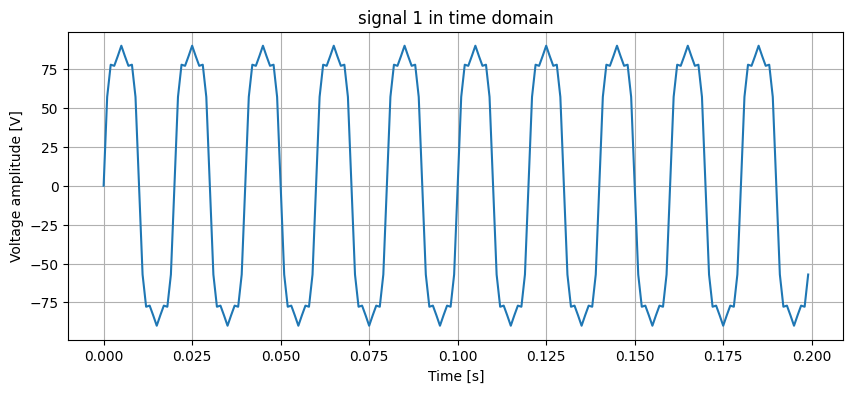

In [152]:
t_1 = signal_1_df["time_s"].values
y_1 = signal_1_df["signal_V"].values  

# plot this using matplotlib

plt.figure(figsize=(10, 4))
plt.plot(t_1, y_1)
plt.title('signal 1 in time domain')
plt.xlabel('Time [s]')
plt.ylabel('Voltage amplitude [V]')
plt.grid(True)
plt.show()

In [153]:
N = len(t_1) # number of samples

dt = t_1[1] - t_1[0] # time step

T_total = t_1[-1] - t_1[0] # total time duration of the signal

df_res = 1 / T_total # frequency resolution

print(f'{N} samples, dt = {dt:.4f} s, T_total = {T_total:.2f} s, df = {df_res:.2f} Hz')

200 samples, dt = 0.0010 s, T_total = 0.20 s, df = 5.03 Hz


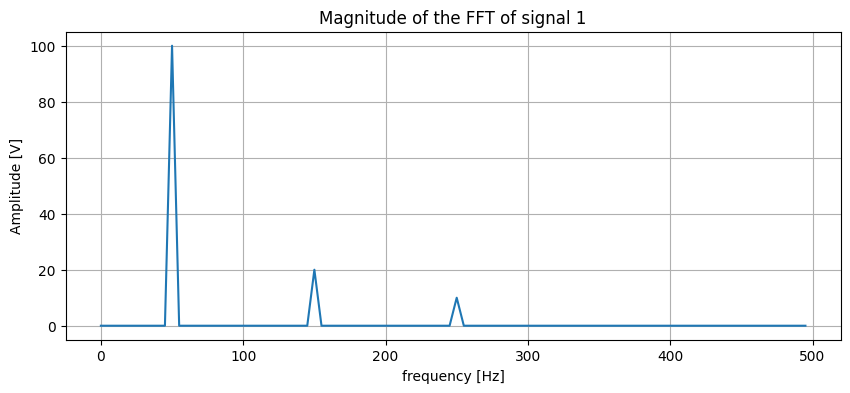

Main frequency component: 50.00 Hz with amplitude 100.00 V
Nyquist frequency: 500.00 Hz


In [154]:
Y = fft(y_1) # compute the FFT of the signal

frequencies = fftfreq(N, dt)[:N//2] # compute the corresponding frequencies for positive frequencies

magnitude = 2.0/N * np.abs(Y[0:N//2]) # compute the magnitude of the FFT and normalize

plt.figure(figsize=(10, 4))
plt.plot(frequencies, magnitude)
plt.title('Magnitude of the FFT of signal 1')
plt.xlabel('frequency [Hz]')
plt.ylabel('Amplitude [V]')
plt.grid(True)
plt.show()

print(f'Main frequency component: {frequencies[np.argmax(magnitude)]:.2f} Hz with amplitude {np.max(magnitude):.2f} V')
print(f'Nyquist frequency: {fs/2:.2f} Hz') # half of sampling frequency is the maximum frequency that can be accurately represented without aliasing

In [155]:
# signal 2

t_2 = signal_2_df["time_s"].values
y_2 = signal_2_df["signal_V"].values
N_2 = len(t_2)
dt_2 = t_2[1] - t_2[0]
T_total_2 = t_2[-1] - t_2[0]
df_res_2 = 1 / T_total_2
print(f'{N_2} samples, dt = {dt_2:.4f} s, T_total = {T_total_2:.2f} s, df = {df_res_2:.2f} Hz')

2000 samples, dt = 0.0001 s, T_total = 0.20 s, df = 5.00 Hz


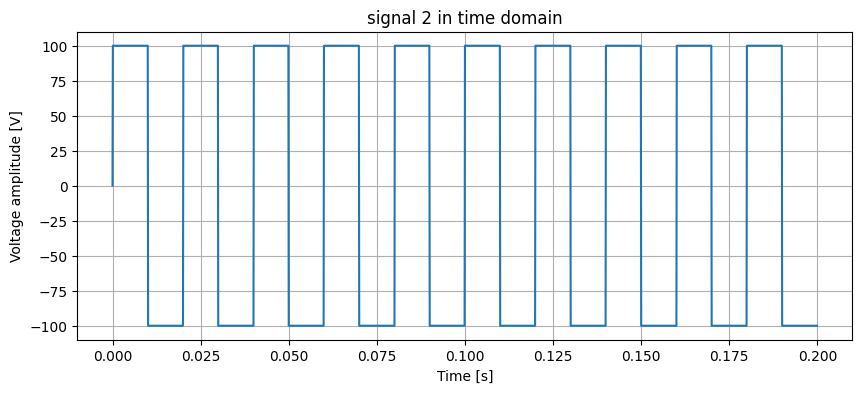

In [156]:
# plot signal 2 in time domain

plt.figure(figsize=(10, 4))
plt.plot(t_2, y_2)
plt.title('signal 2 in time domain')
plt.xlabel('Time [s]')
plt.ylabel('Voltage amplitude [V]')
plt.grid(True)
plt.show()

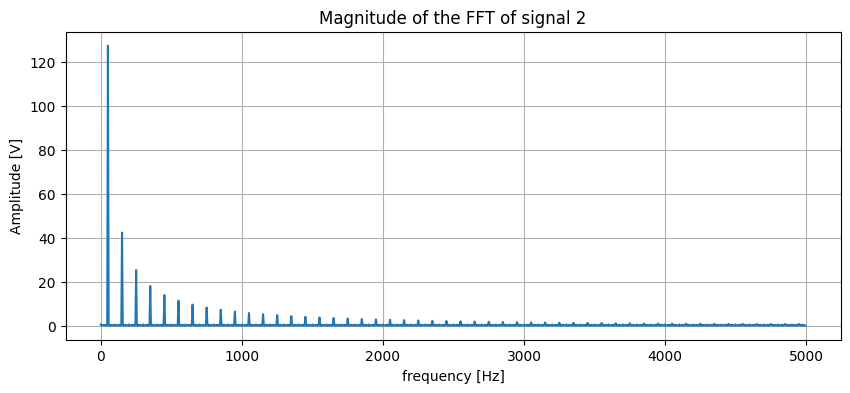

In [157]:
# calculate and plot FFT for signal 2

Y_2 = fft(y_2)
frequencies_2 = fftfreq(N_2, dt_2)[:N_2//2]
magnitude_2 = 2.0/N_2 * np.abs(Y_2[0:N_2//2])
plt.figure(figsize=(10, 4))
plt.plot(frequencies_2, magnitude_2)
plt.title('Magnitude of the FFT of signal 2')
plt.xlabel('frequency [Hz]')
plt.ylabel('Amplitude [V]')
plt.grid(True)
plt.show()

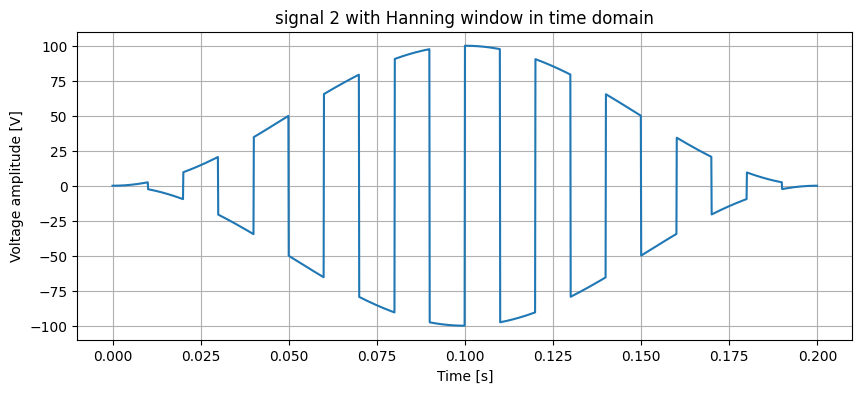

In [158]:
# spectral leakage detected - use hanning window to reduce it

window = np.hanning(N_2)
y_2_windowed = y_2 * window
Y_2_windowed = fft(y_2_windowed)

# plot the signal with hanning window in time domain to see the effect of the window

plt.figure(figsize=(10, 4))
plt.plot(t_2, y_2_windowed)
plt.title('signal 2 with Hanning window in time domain')
plt.xlabel('Time [s]')
plt.ylabel('Voltage amplitude [V]')
plt.grid(True)
plt.show()

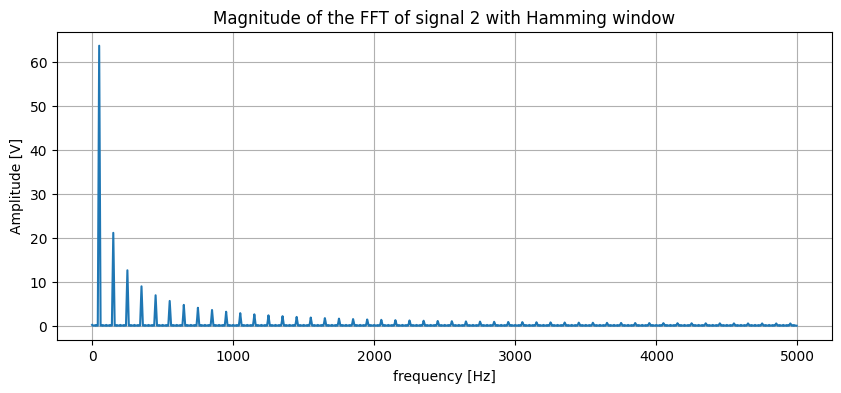

In [159]:
# plot the FFT of the windowed signal to see the reduction in spectral leakage?

magnitude_2_windowed = 2.0/N_2 * np.abs(Y_2_windowed[0:N_2//2])
plt.figure(figsize=(10, 4))
plt.plot(frequencies_2, magnitude_2_windowed)
plt.title('Magnitude of the FFT of signal 2 with Hamming window')
plt.xlabel('frequency [Hz]')
plt.ylabel('Amplitude [V]')
plt.grid(True)
plt.show()



As we can see there is some spectral leakage in the second signal, and even though we applied the hanning window to whole function, it still persists. Why does it persist? That I unfortunately do not know.

In [160]:
# aliasing example with signal 3

f1,A1 = 50, 100 # frequency and amplitude of first component
f2,A2 = 950, 30 # frequency and amplitude of second component
duration = 0.2 # duration of the signal in seconds

t_high = np.linspace(0,duration,10000,endpoint=False) # high resolution time vector for generating the signal

y_high = A1 * np.sin(2*np.pi*f1*t_high) + A2 * np.sin(2*np.pi*f2*t_high) # generate the signal with two frequency components

In [ ]:
#correct sampling frequency for signal 3 to avoid aliasing

fs1 = 5000 # 5kHz

t1 = np.arange(0, duration, 1/fs1) # time vector for sampling at fs1    

y1 = A1 * np.sin(2*np.pi*f1*t1) + A2 * np.sin(2*np.pi*f2*t1) # sampled signal at fs1

# #plot the original high resolution signal and the sampled signal to see the effect of aliasing
# plt.figure(figsize=(10, 4))
# plt.plot(t_high, y_high, label='High resolution signal')
# plt.plot(t1, y1, '-o', label='Sampled signal at 5 kHz')
# plt.title('Aliasing example with signal 3 with correct sampling frequency')
# plt.xlabel('Time [s]')
# plt.ylabel('Voltage amplitude [V]')
# plt.grid(True)
# plt.legend()
# plt.show()

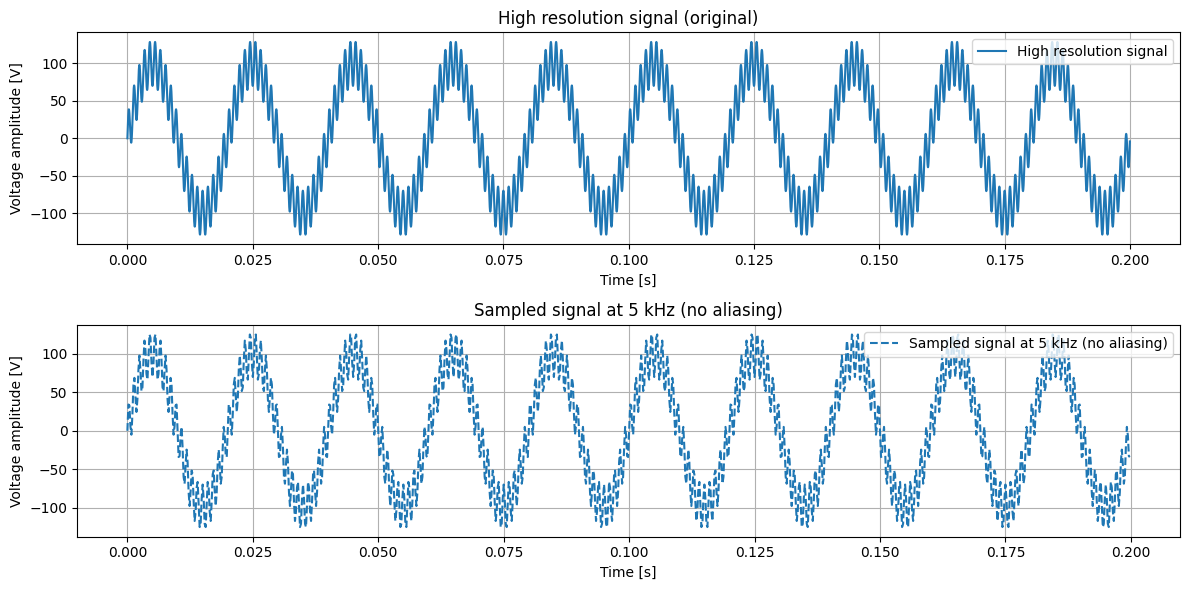

In [162]:
#split it into two subplots to better see the effect of aliasing

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t_high, y_high, label='High resolution signal')
plt.title('High resolution signal (original)')
plt.xlabel('Time [s]')
plt.ylabel('Voltage amplitude [V]')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t1, y1, '--', label='Sampled signal at 5 kHz (no aliasing)')
plt.title('Sampled signal at 5 kHz (no aliasing)')
plt.xlabel('Time [s]')
plt.ylabel('Voltage amplitude [V]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# now sample the same signal at a lower sampling frequency to see aliasing

fs2 = 800 # 800 Hz, below the Nyquist frequency for the 950 Hz component

t2 = np.arange(0, duration, 1/fs2) # time vector for sampling at fs2

y2 = A1 * np.sin(2*np.pi*f1*t2) + A2 * np.sin(2*np.pi*f2*t2) # sampled signal at fs2

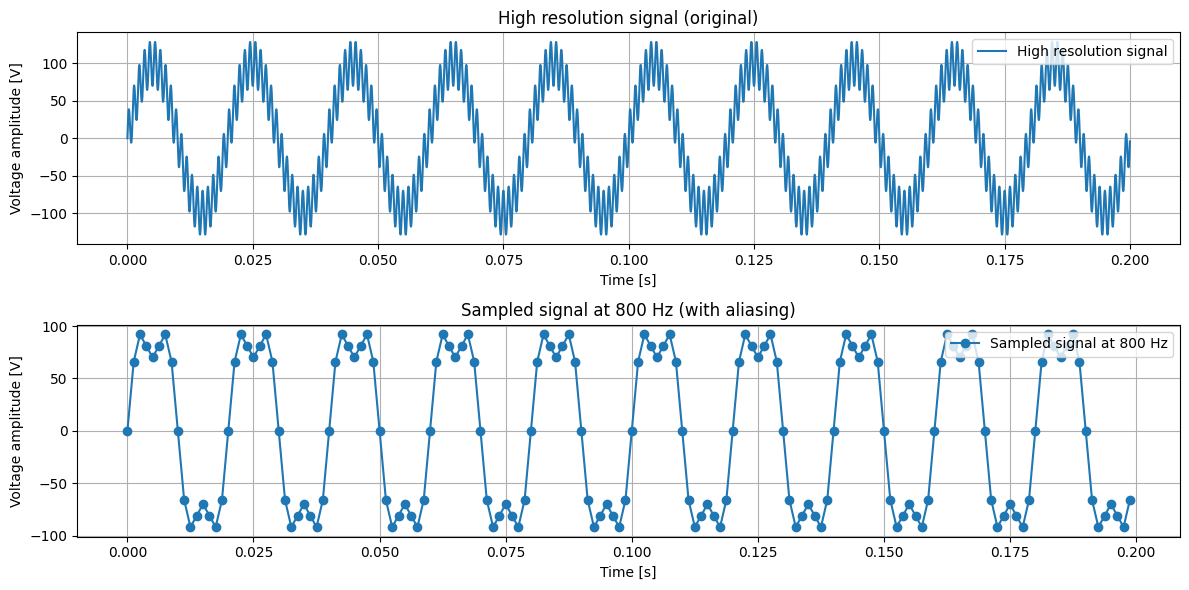

In [164]:
# plot the original high resolution signal and the aliased signal to see the effect of aliasing

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t_high, y_high, label='High resolution signal')
plt.title('High resolution signal (original)')
plt.xlabel('Time [s]')
plt.ylabel('Voltage amplitude [V]')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t2, y2, '-o', label='Sampled signal at 800 Hz')
plt.title('Sampled signal at 800 Hz (with aliasing)')
plt.xlabel('Time [s]')
plt.ylabel('Voltage amplitude [V]')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [165]:
#calculate fft of signal 3 sampled at fs2 and fs1 to see the aliased frequency components for both sampling frequencies

N1 = len(t1)
dt1 = t1[1] - t1[0]
Y1 = fft(y1)
frequencies1 = fftfreq(N1, dt1)[:N1//2]
magnitude1 = 2.0/N1 * np.abs(Y1[0:N1//2])

N2 = len(t2)
dt2 = t2[1] - t2[0]
Y2 = fft(y2)
frequencies2 = fftfreq(N2, dt2)[:N2//2]
magnitude2 = 2.0/N2 * np.abs(Y2[0:N2//2])


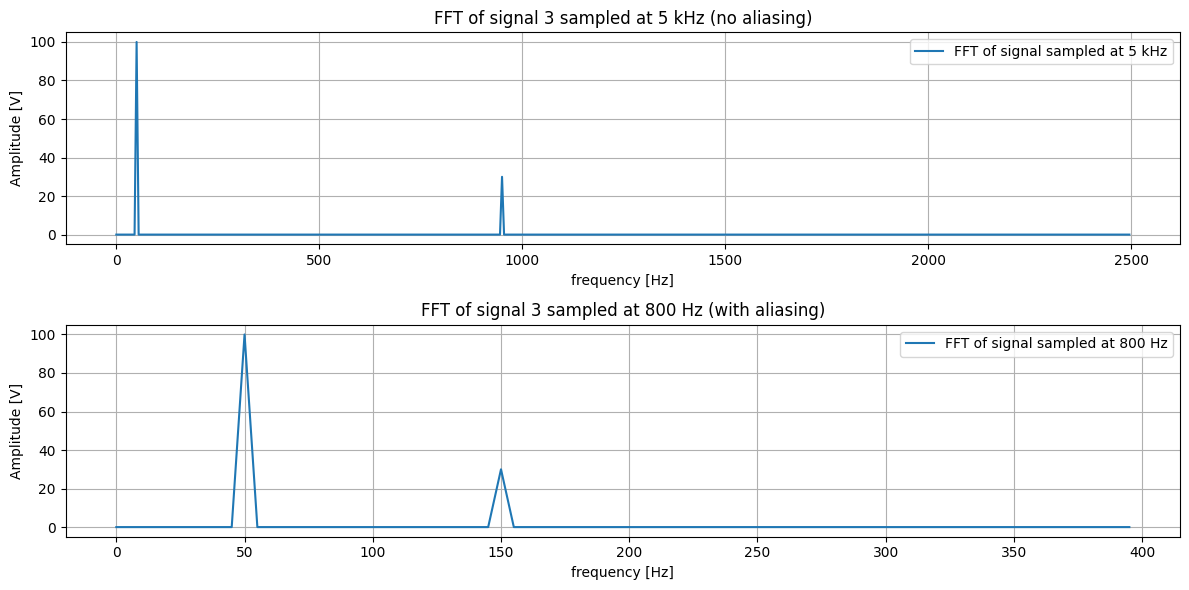

In [166]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(frequencies1, magnitude1, label='FFT of signal sampled at 5 kHz')
plt.title('FFT of signal 3 sampled at 5 kHz (no aliasing)')
plt.xlabel('frequency [Hz]')
plt.ylabel('Amplitude [V]')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(frequencies2, magnitude2, label='FFT of signal sampled at 800 Hz')
plt.title('FFT of signal 3 sampled at 800 Hz (with aliasing)')
plt.xlabel('frequency [Hz]')
plt.ylabel('Amplitude [V]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**1. What happened to the 950 Hz component?**

As we can see here, at 5kHz sampling the harmonics are equal to 50 Hz and 950 Hz, correctly according to the text. For the 800 Hz sampling frequency the first harmonic is at 50 Hz just like with 5kHz sampling, however the second one is way off - 150 Hz instead of 950 Hz. We have encountered aliasing, due to the fact that the sampling frequency is smaller that the second harmonics frequency at 950 Hz.

**2. Why does this phenomenon occur?**

This phenomenon occurs because of the Nyquist-Shannon theorem, which states that the sampling frequency must be at least two times bigger than the biggest frequency occuring in the signal. The top registered frequency then will be the Nyquist frequency (fn = fs/2). For the 800 Hz example, this frequency will be equal to 400 Hz, which is way less than the biggest frequency present in the signal (950 Hz). The aliased frequency will be offset by a multiple of the Nyquist frequency, which will give us the second harmonic at 150 Hz:
```
 950 Hz - 2 * 400 Hz = 150 Hz.
```